## 📚 Import Libraries

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
from sklearn.feature_extraction.text import CountVectorizer

# Similarity Calculation
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
df_m = pd.read_csv("movies.csv")
df_r = pd.read_csv("ratings.csv")

In [4]:
df_m.head(6)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller


In [5]:
df_r.head(6)

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510
5,1,1088,4.0,1147868495


In [7]:
df_m.shape

(62423, 3)

In [8]:
df_r.shape

(25000095, 4)

In [9]:
df_r.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000095 entries, 0 to 25000094
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 762.9 MB


In [10]:
df_m.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  62423 non-null  int64 
 1   title    62423 non-null  object
 2   genres   62423 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.4+ MB


In [11]:
df_m.describe()

,movieId
count,62423.000000
mean,122220.387646
std,63264.744844
min,1.000000
25%,82146.500000
50%,138022.000000
75%,173222.000000
max,209171.000000


In [12]:
df_r.describe()

,userId,movieId,rating,timestamp
count,2.500010e+07,2.500010e+07,2.500010e+07,2.500010e+07
mean,8.118928e+04,2.138798e+04,3.533854e+00,1.215601e+09
std,4.679172e+04,3.919886e+04,1.060744e+00,2.268758e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,4.051000e+04,1.196000e+03,3.000000e+00,1.011747e+09
50%,8.091400e+04,2.947000e+03,3.500000e+00,1.198868e+09
75%,1.215570e+05,8.623000e+03,4.000000e+00,1.447205e+09
max,1.625410e+05,2.091710e+05,5.000000e+00,1.574328e+09


## 🧹 Data Preprocessing

### 📌 Check Missing Values

In [15]:
df_m.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [16]:
df_r.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

### 📌 Check Duplicate Values

In [17]:
df_m.duplicated().sum()

0

In [18]:
df_r.duplicated().sum()

0

### 📌 Merge Dataset


In [30]:
# Fill missing genres with empty string
df_m['genres'] = df_m['genres'].fillna('')

In [19]:
df = pd.merge(df_r, df_m, on='movieId')

df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,296,5.0,1147880044,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
1,1,306,3.5,1147868817,Three Colors: Red (Trois couleurs: Rouge) (1994),Drama
2,1,307,5.0,1147868828,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama
3,1,665,5.0,1147878820,Underground (1995),Comedy|Drama|War
4,1,899,3.5,1147868510,Singin' in the Rain (1952),Comedy|Musical|Romance


In [20]:
print("Merged Dataset Shape :", df.shape)

Merged Dataset Shape : (25000095, 6)


In [21]:
df.columns

Index(['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres'], dtype='object')

## 📊 Exploratory Data Analysis (EDA)

### 🎥 Top Rated Movies

In [ ]:
# Average rating of each movie..........
top_rated = df.groupby('title')['rating'].mean().sort_values(ascending=False)

# Convert into dataframe...........
top_rated = pd.DataFrame(top_rated)

top_rated.head(10)

,rating
title,
Full of Grace (2015),5.0
Geordie (1955),5.0
Garfield In Paradise (1986),5.0
Lost Woods (2012),5.0
Garfield in the Rough (1984),5.0
Lost Time (2014),5.0
Who Killed Chea Vichea? (2010),5.0
Lost Rivers (2013),5.0
Who Killed Johnny (2013),5.0


### ⭐ Most Popular Movies

In [23]:
# Count ratings for each movie.............
popular_movies = df.groupby('title')['rating'].count().sort_values(ascending=False)

# Convert into dataframe...........
popular_movies = pd.DataFrame(popular_movies)

popular_movies.head(10)

,rating
title,
Forrest Gump (1994),81491
"Shawshank Redemption, The (1994)",81482
Pulp Fiction (1994),79672
"Silence of the Lambs, The (1991)",74127
"Matrix, The (1999)",72674
Star Wars: Episode IV - A New Hope (1977),68717
Jurassic Park (1993),64144
Schindler's List (1993),60411
Braveheart (1995),59184


### 📈 Rating Distribution

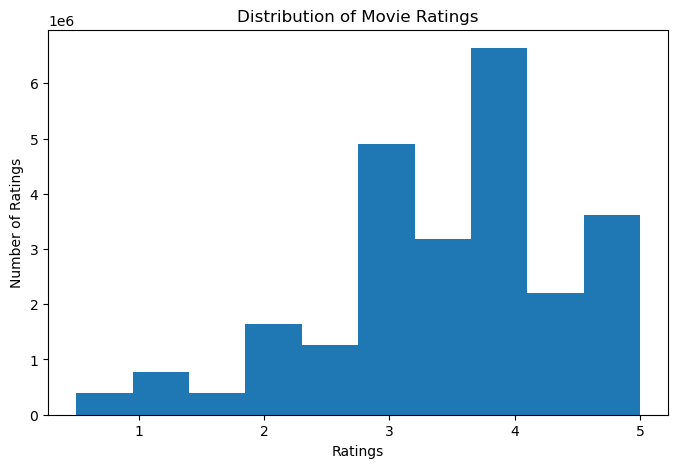

In [25]:
plt.figure(figsize=(8,5))

plt.hist(df['rating'])

plt.xlabel("Ratings")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Movie Ratings")

plt.show()

### 🎭 Genre Analysis

In [26]:
# Split genres............
genres = df_m['genres'].str.split('|').explode()

# Count genres...........
genre_count = genres.value_counts()

genre_count

genres
Drama                 25606
Comedy                16870
Thriller               8654
Romance                7719
Action                 7348
Horror                 5989
Documentary            5605
Crime                  5319
(no genres listed)     5062
Adventure              4145
Sci-Fi                 3595
Children               2935
Animation              2929
Mystery                2925
Fantasy                2731
War                    1874
Western                1399
Musical                1054
Film-Noir               353
IMAX                    195
Name: count, dtype: int64

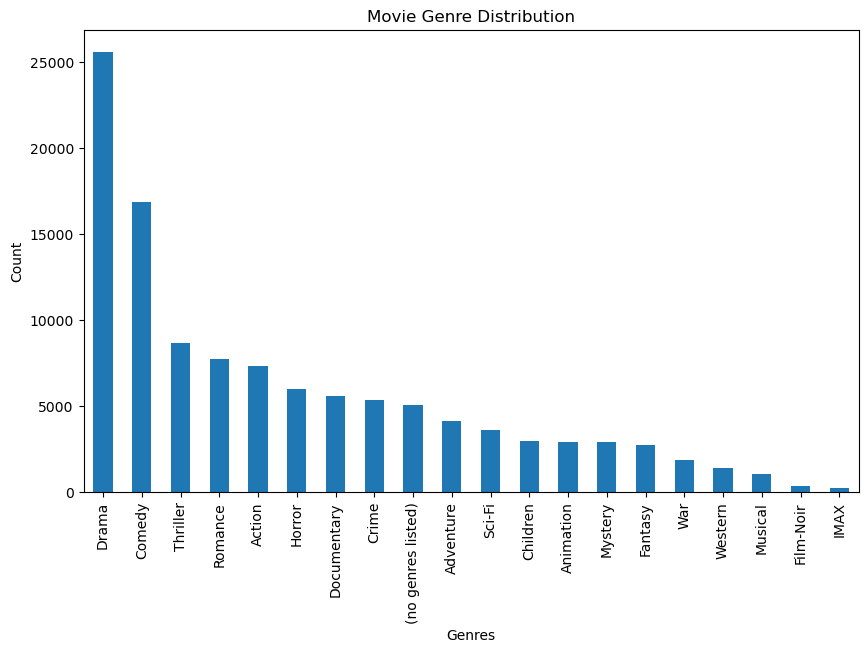

In [27]:
plt.figure(figsize=(10,6))

genre_count.plot(kind='bar')

plt.xlabel("Genres")
plt.ylabel("Count")
plt.title("Movie Genre Distribution")

plt.show()

👤 Most Active Users ......................

In [28]:
# Extract year
df_m['year'] = df_m['title'].str.extract(r'\((\d{4})\)')

# Display first rows
df_m.head()

,movieId,title,genres,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995
2,3,Grumpier Old Men (1995),Comedy|Romance,1995
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995
4,5,Father of the Bride Part II (1995),Comedy,1995


📉 Movies Released Trend

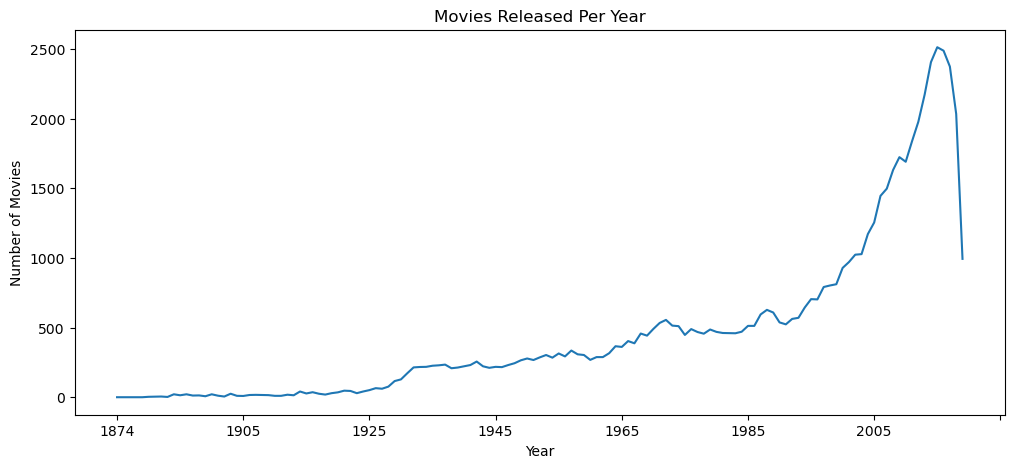

In [29]:
movies_per_year = df_m['year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

movies_per_year.plot()

plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.title("Movies Released Per Year")

plt.show()

## 🤖 Building the Movie Recommendation System

In [ ]:
movies_data = df_m[['movieId', 'title', 'genres']]

movies_data.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [32]:
movies_data['genres'] = movies_data['genres'].fillna('')

In [34]:
# Initialize CountVectorizer
cv = CountVectorizer(tokenizer=lambda x: x.split('|'))

# Convert genres into matrix
count_matrix = cv.fit_transform(movies_data['genres'])

print(count_matrix)

print(count_matrix.shape)

  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (0, 5)	1
  (0, 9)	1
  (1, 2)	1
  (1, 4)	1
  (1, 9)	1
  (2, 5)	1
  (2, 15)	1
  (3, 5)	1
  (3, 15)	1
  (3, 8)	1
  (4, 5)	1
  (5, 1)	1
  (5, 6)	1
  (5, 17)	1
  (6, 5)	1
  (6, 15)	1
  (7, 2)	1
  (7, 4)	1
  (8, 1)	1
  (9, 2)	1
  (9, 1)	1
  (9, 17)	1
  :	:
  (62407, 0)	1
  (62408, 9)	1
  (62408, 7)	1
  (62409, 19)	1
  (62410, 8)	1
  (62411, 5)	1
  (62412, 3)	1
  (62412, 7)	1
  (62413, 8)	1
  (62414, 6)	1
  (62414, 11)	1
  (62415, 0)	1
  (62416, 5)	1
  (62416, 8)	1
  (62417, 5)	1
  (62417, 15)	1
  (62417, 1)	1
  (62418, 8)	1
  (62419, 7)	1
  (62420, 5)	1
  (62420, 8)	1
  (62421, 0)	1
  (62422, 2)	1
  (62422, 8)	1
  (62422, 1)	1
(62423, 20)


In [35]:
tfidf = TfidfVectorizer(token_pattern=r'[^|]+')
tfidf_matrix = tfidf.fit_transform(df_m['genres'])

model = NearestNeighbors( metric='cosine', algorithm='brute')
model.fit(tfidf_matrix)

NearestNeighbors(algorithm='brute', metric='cosine')

In [36]:
def recommend(movie_name):

    movie_name = movie_name.lower()

    # Find movie index
    idx = df_m[
        df_m['title'].str.lower() == movie_name
    ].index

    if len(idx) == 0:
        print("Movie not found!")
        return

    idx = idx[0]

    # Find nearest neighbors
    distances, indices = model.kneighbors(
        tfidf_matrix[idx],
        n_neighbors=11
    )

    print(f"\n🎬 Recommended Movies for '{df_m.iloc[idx]['title']}'\n")

    for i in range(1, len(indices[0])):

        movie_idx = indices[0][i]

        print(df_m.iloc[movie_idx]['title'])

In [37]:
recommend("Toy Story (1995)")


🎬 Recommended Movies for 'Toy Story (1995)'

Missing Link (2019)
The Dragon Spell (2016)
Tangled: Before Ever After (2017)
Emperor's New Groove, The (2000)
Dragons: Dawn Of The Dragon Racers (2014)
Wild, The (2006)
Moana (2016)
Toy Story (1995)
Asterix and the Vikings (Astérix et les Vikings) (2006)
Shrek the Third (2007)


2026-07-19 11:52:33.118 
  command:

    streamlit run d:\anaconda\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]


DeltaGenerator()

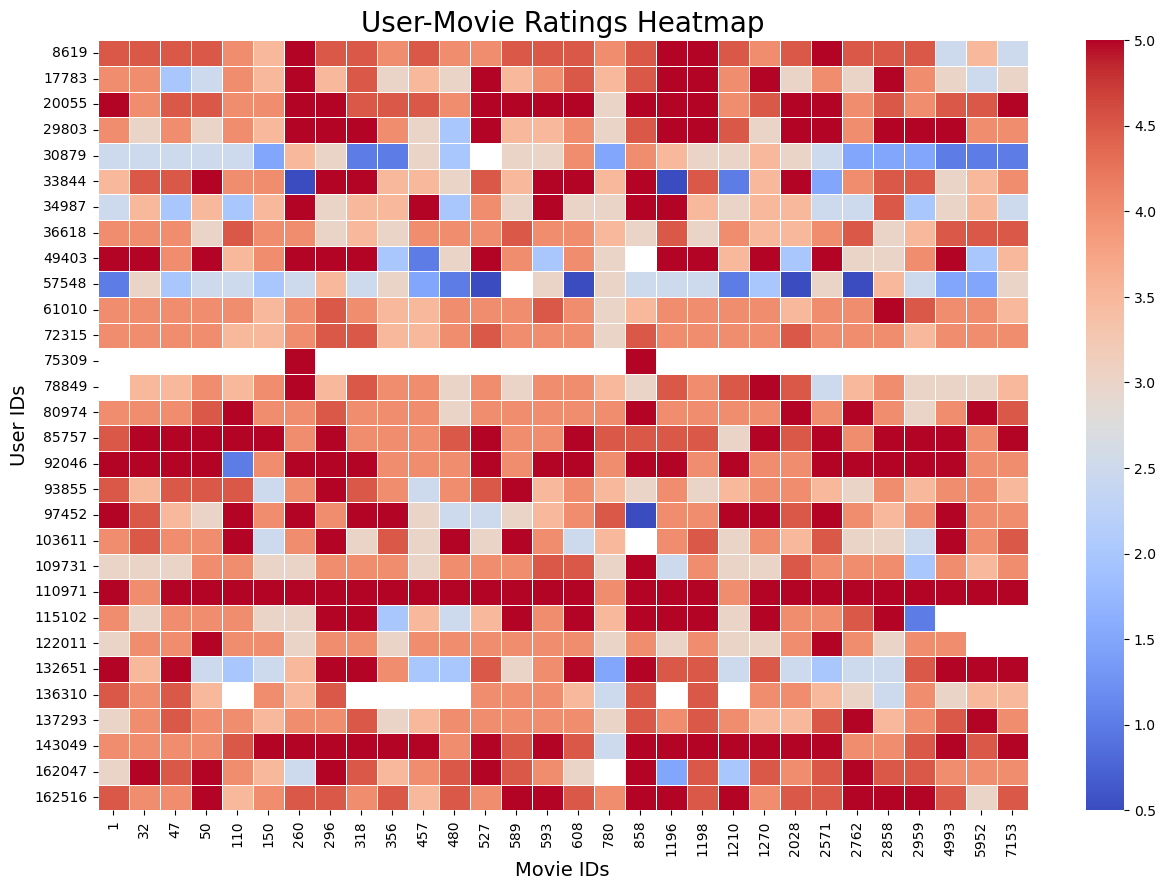

In [38]:
# ==========================================
# USER-MOVIE RATINGS HEATMAP
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st 

# Reload data after kernel restart
df_rating = pd.read_csv("ratings.csv", dtype={'userId': 'int32', 'movieId': 'int32', 'rating': 'float32'})

# Filter to top 30 users and top 30 movies BEFORE pivot
top_movies = df_rating['movieId'].value_counts().head(30).index
top_users  = df_rating['userId'].value_counts().head(30).index

filtered = df_rating[
    df_rating['movieId'].isin(top_movies) &
    df_rating['userId'].isin(top_users)
]

# Create User-Movie Matrix
movie_matrix = filtered.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

# Select smaller portion for visualization
heatmap_data = movie_matrix.iloc[:30, :30]

# Create Heatmap
fig=plt.figure(figsize=(15,10))
sns.heatmap(
    heatmap_data,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    cbar=True
)

# Titles and Labels
plt.title("User-Movie Ratings Heatmap", fontsize=20)
plt.xlabel("Movie IDs", fontsize=14)
plt.ylabel("User IDs", fontsize=14)

st.pyplot(fig)